<a href="https://colab.research.google.com/github/caffeicsatyam/Book_Recommendation_System/blob/main/book_recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'book-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/book-recommendation-dataset


In [3]:
os.listdir('/kaggle/input/book-recommendation-dataset')

['Ratings.csv',
 'Users.csv',
 'classicRec.png',
 'Books.csv',
 'DeepRec.png',
 'recsys_taxonomy2.png']

In [4]:
ratings = pd.read_csv('/kaggle/input/book-recommendation-dataset/Ratings.csv')
users = pd.read_csv('/kaggle/input/book-recommendation-dataset/Users.csv')
books = pd.read_csv('/kaggle/input/book-recommendation-dataset/Books.csv')

/tmp/ipython-input-336120385.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('/kaggle/input/book-recommendation-dataset/Books.csv')


In [5]:
# Print Image

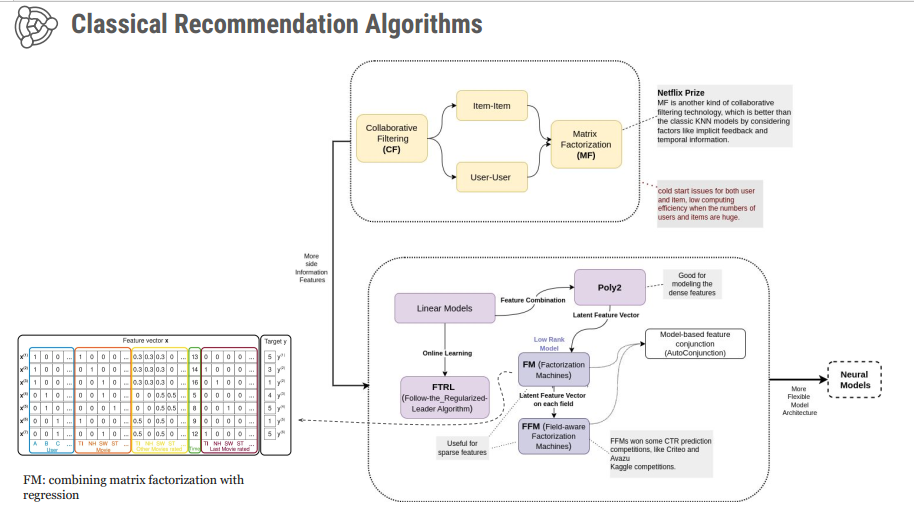

In [6]:
from IPython.display import Image

# Assuming the image is in the dataset path identified earlier
image_path = '/kaggle/input/book-recommendation-dataset/classicRec.png'
Image(filename=image_path)

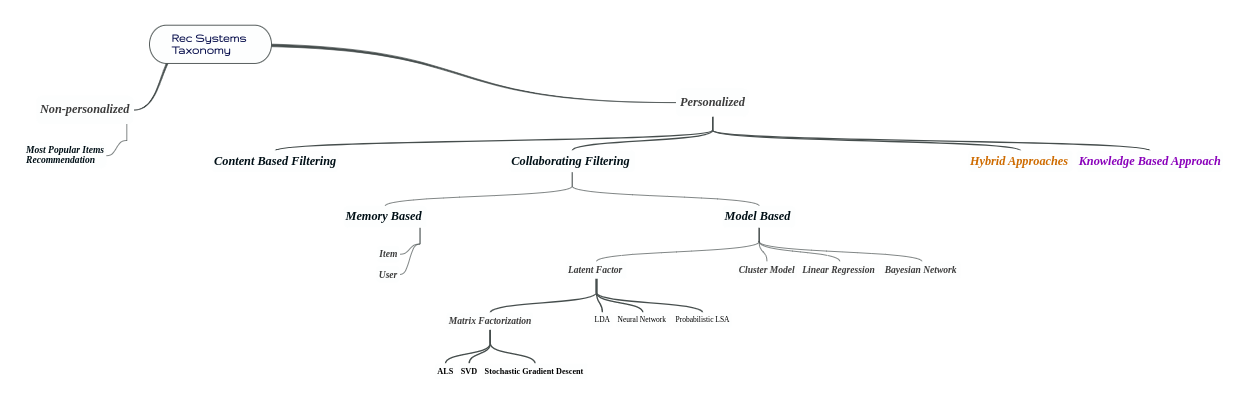

In [7]:
from IPython.display import Image

# Assuming the image is in the dataset path identified earlier
image_path = '/kaggle/input/book-recommendation-dataset/recsys_taxonomy2.png'
Image(filename=image_path)

In [8]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [9]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [10]:
users.columns, books.columns, ratings.columns

(Index(['User-ID', 'Location', 'Age'], dtype='object'),
 Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
        'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
       dtype='object'),
 Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object'))

In [11]:
print(books.shape, users.shape, ratings.shape)

(271360, 8) (278858, 3) (1149780, 3)


In [12]:
print(books.isnull().sum(), users.isnull().sum(), ratings.isnull().sum())

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64 User-ID          0
Location         0
Age         110762
dtype: int64 User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [13]:
print(books.duplicated().sum(), users.duplicated().sum(), ratings.duplicated().sum())

0 0 0


In [14]:
users.shape

(278858, 3)

In [15]:
#total of users that gave multiple no of ratings
users_multiple_ratings = ratings.groupby("User-ID").size()
total_users = (users_multiple_ratings > 1).sum()

In [16]:
total_users

np.int64(46117)

In [17]:
ratings_per_user = ratings.groupby("User-ID").size()

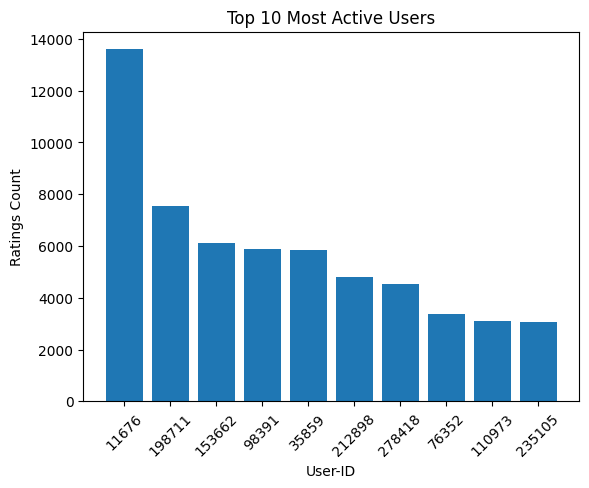

In [18]:
top_users = ratings_per_user.sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_users.index.astype(str), top_users.values)
plt.xlabel("User-ID")
plt.ylabel("Ratings Count")
plt.title("Top 10 Most Active Users")
plt.xticks(rotation=45)
plt.show()


# Popularity Based System

In [19]:
ratings_with_name = ratings.merge(books, on="ISBN")

In [20]:
num_ratings_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_ratings_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_ratings_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [21]:
avg_ratings_df = (ratings_with_name.groupby('Book-Title')['Book-Rating'].mean().reset_index())

In [22]:
avg_ratings_df.rename(columns={'Book-Rating':'avg_rating'},inplace=True)
avg_ratings_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [23]:
popularity_df = num_ratings_df.merge(avg_ratings_df,on='Book-Title')
popularity_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [24]:
popular_df = popularity_df[popularity_df['num_ratings'] >= 250].sort_values('avg_rating',ascending=False).head(50)

In [25]:
popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

In [26]:
popularity_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


# Collaborative Filtering

In [27]:
x = ratings_with_name.groupby("User-ID").count()['Book-Rating'] > 200
padhe_likhe_users = x[x].index

In [28]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(padhe_likhe_users)]

In [29]:
y = filtered_rating.groupby("Book-Title").count()['Book-Rating'] >= 50

In [30]:
famous_books = y[y].index

In [31]:
famous_books

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='Book-Title', length=706)

In [32]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [33]:
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [34]:
pt.fillna(0, inplace = True)

In [35]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_score = cosine_similarity(pt)

In [37]:
similarity_score.shape

(706, 706)

In [38]:
from re import template
def recommend(book_name):
  # book name
  index = np.where(pt.index == book_name)[0][0]
  similar_items = sorted(list(enumerate(similarity_score[index])), key=lambda x:x[1], reverse=True)[1:6]

  data = []
  for i in similar_items:
    item = []
    temp_df = books[books['Book-Title'] == pt.index[i[0]]]
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Publisher'].values))
    data.append(item)
  return data


In [39]:
items = recommend('1984')

In [40]:
items

[['Animal Farm',
  'George Orwell',
  'http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg',
  'Signet'],
 ["The Handmaid's Tale",
  'Margaret Atwood',
  'http://images.amazon.com/images/P/0449212602.01.MZZZZZZZ.jpg',
  'Fawcett Books'],
 ['Brave New World',
  'Aldous Huxley',
  'http://images.amazon.com/images/P/0060809833.01.MZZZZZZZ.jpg',
  'Harpercollins'],
 ['The Vampire Lestat (Vampire Chronicles, Book II)',
  'ANNE RICE',
  'http://images.amazon.com/images/P/0345313860.01.MZZZZZZZ.jpg',
  'Ballantine Books'],
 ['The Hours : A Novel',
  'Michael Cunningham',
  'http://images.amazon.com/images/P/0312243022.01.MZZZZZZZ.jpg',
  'Picador']]

In [41]:
recommend('The Return of the King (The Lord of the Rings, Part 3)')

[['The Two Towers (The Lord of the Rings, Part 2)',
  'J.R.R. TOLKIEN',
  'http://images.amazon.com/images/P/0345339711.01.MZZZZZZZ.jpg',
  'Del Rey'],
 ['The Fellowship of the Ring (The Lord of the Rings, Part 1)',
  'J.R.R. TOLKIEN',
  'http://images.amazon.com/images/P/0345339703.01.MZZZZZZZ.jpg',
  'Del Rey'],
 ['Scarlett : The Sequel to Margaret Mitchell\'s \\Gone With the Wind\\""',
  'Alexandra Ripley',
  'http://images.amazon.com/images/P/0446363251.01.MZZZZZZZ.jpg',
  'Warner Books'],
 ['Red Storm Rising',
  'Tom Clancy',
  'http://images.amazon.com/images/P/042510107X.01.MZZZZZZZ.jpg',
  'Berkley Publishing Group'],
 ['Midnight in the Garden of Good and Evil',
  'John Berendt',
  'http://images.amazon.com/images/P/0679751521.01.MZZZZZZZ.jpg',
  'Vintage Books USA']]

In [42]:
import pickle
pickle.dump(books,open('popular.pkl','wb'))

In [43]:
pickle.dump(popular_df,open('popular_df.pkl', 'wb'))

In [44]:
pickle.dump(pt,open('pt.pkl','wb'))
pickle.dump(books,open('books.pkl','wb'))
pickle.dump(similarity_score,open('similarity_score.pkl','wb'))

array([[1.        , 0.10255025, 0.01220856, ..., 0.12110367, 0.07347567,
        0.04316046],
       [0.10255025, 1.        , 0.2364573 , ..., 0.07446129, 0.16773875,
        0.14263397],
       [0.01220856, 0.2364573 , 1.        , ..., 0.04558758, 0.04938579,
        0.10796119],
       ...,
       [0.12110367, 0.07446129, 0.04558758, ..., 1.        , 0.07085128,
        0.0196177 ],
       [0.07347567, 0.16773875, 0.04938579, ..., 0.07085128, 1.        ,
        0.10602962],
       [0.04316046, 0.14263397, 0.10796119, ..., 0.0196177 , 0.10602962,
        1.        ]])